In [21]:
!pip install tqdm

## 📅 [5차 시도] 초미세 결함 대응을 위한 Stitching Augmentation (V5)

### 1. 실험 배경 및 목적
- **문제점**: 실무 환경에서 결함(특히 Pinhole)은 이미지 전체 면적에 비해 매우 미세한 크기로 존재함. 기존 학습 데이터로는 이러한 '초소형 객체' 탐지에 한계가 있음.
- **해결책**: 3x3 그리드 합성을 통해 결함의 상대적 크기를 **1/9**로 축소시킨 고난도 훈련 데이터 생성함

### 2. 증강 상세 (Methodology)
- **그리드 구성**: 중앙 1칸에는 결함 이미지를 놓고, 주변 8칸에는 양품( 기준 충족 ) 이미지 배치
- **좌표 변환**: 
  - $x_{new} = (x_{orig} + 1) / 3$
  - $y_{new} = (y_{orig} + 1) / 3$
  - $w_{new} = w_{orig} / 3, \quad h_{new} = h_{orig} / 3$
- **데이터 규모**: 기존 9,859장에서 증강본을 추가하여 약 2만 장 규모의 Train 데이터 확보

### 3. 기대 효과
- AI가 광범위한 정상 배경 속에서 아주 작은 결함을 찾아내는 **변별력(Discriminative Power)** 강화.
- 실제 현장에서 발생할 수 있는 '초미세 균열 및 핀홀' 탐지 성공률 극대화.

In [22]:
import json
from tqdm import tqdm

# 양품 이미지 색상 프로파일 생성 (1회만 실행)
def create_normal_image_profiles(normal_img_dir, normal_files, save_path):
    """모든 양품 이미지의 LAB 색상 평균값 계산 및 저장"""
    profiles = {}
    
    print(f"🔍 {len(normal_files)}개 양품 이미지의 색상 프로파일 생성 중...")
    
    for normal_file in tqdm(normal_files):
        img_path = os.path.join(normal_img_dir, normal_file)
        img = cv2.imread(img_path)
        
        if img is None:
            continue
        
        # BGR -> LAB 변환
        lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
        
        # 평균 LAB 값 계산
        mean_lab = np.mean(lab.reshape(-1, 3), axis=0)
        
        profiles[normal_file] = {
            'lab_mean': mean_lab.tolist()
        }
    
    # JSON으로 저장
    with open(save_path, 'w') as f:
        json.dump(profiles, f, indent=2)
    
    print(f"✅ 프로파일 저장 완료: {save_path}")
    print(f"   총 {len(profiles)}개 이미지 프로파일 생성됨\n")
    
    return profiles

# 프로파일 파일 경로
profile_path = os.path.join(base_path, 'normal_profiles.json')

# 프로파일이 이미 존재하면 로드, 없으면 생성
if os.path.exists(profile_path):
    print(f"📂 기존 프로파일 로드 중: {profile_path}")
    with open(profile_path, 'r') as f:
        normal_profiles = json.load(f)
    print(f"✅ {len(normal_profiles)}개 프로파일 로드 완료\n")
else:
    normal_profiles = create_normal_image_profiles(normal_img_dir, normal_files, profile_path)

📂 기존 프로파일 로드 중: C:\Users\SSAFY\Desktop\SafeDeck_Data\normal_profiles.json
✅ 1043개 프로파일 로드 완료



In [23]:
# 배경 색상 추출 및 유사도 매칭 함수

def extract_defect_background_color(img, labels):
    """바운딩 박스 외부의 배경 색상 추출 (LAB 평균값)"""
    h, w = img.shape[:2]
    mask = np.ones((h, w), dtype=np.uint8) * 255
    
    # 결함 영역 마스킹 (바운딩 박스 내부를 0으로 설정)
    for label in labels:
        parts = label.strip().split()
        if len(parts) < 5:
            continue
        
        cls, x, y, nw, nh = map(float, parts)
        x1 = max(0, int((x - nw/2) * w))
        y1 = max(0, int((y - nh/2) * h))
        x2 = min(w, int((x + nw/2) * w))
        y2 = min(h, int((y + nh/2) * h))
        
        mask[y1:y2, x1:x2] = 0
    
    # 마스크 외부(배경) 영역의 평균 LAB 색상
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    background_pixels = lab[mask == 255]
    
    if len(background_pixels) == 0:
        # 배경이 없으면 전체 이미지 평균 사용
        mean_lab = np.mean(lab.reshape(-1, 3), axis=0)
        std_lab = np.std(lab.reshape(-1, 3), axis=0)
    else:
        mean_lab = np.mean(background_pixels, axis=0)
        std_lab = np.std(background_pixels, axis=0)
    
    return mean_lab, std_lab


def select_best_matching_normal_image(defect_lab_mean, normal_profiles):
    """색상 유사도 기반 가장 유사한 양품 이미지 선택 (Top-1)"""
    min_distance = float('inf')
    best_match = None
    
    for normal_file, profile in normal_profiles.items():
        normal_lab = np.array(profile['lab_mean'])
        
        # Delta E (CIE76) 거리 계산
        delta_e = np.sqrt(np.sum((defect_lab_mean - normal_lab) ** 2))
        
        if delta_e < min_distance:
            min_distance = delta_e
            best_match = normal_file
    
    return best_match, min_distance


def color_transfer_lab(source_img, target_mean, target_std, source_mean=None, source_std=None):
    """LAB 색상 공간에서 색상 전이 (Color Transfer)"""
    # BGR -> LAB
    lab = cv2.cvtColor(source_img, cv2.COLOR_BGR2LAB).astype(np.float32)
    
    # 소스 이미지의 평균/표준편차 계산 (제공되지 않은 경우)
    if source_mean is None or source_std is None:
        source_mean = np.mean(lab.reshape(-1, 3), axis=0)
        source_std = np.std(lab.reshape(-1, 3), axis=0)
    
    # 색상 전이 알고리즘
    # 1) 소스 이미지를 평균 0, 표준편차 1로 정규화
    lab_normalized = (lab - source_mean) / (source_std + 1e-6)
    
    # 2) 타겟의 평균과 표준편차로 재조정
    lab_transferred = lab_normalized * target_std + target_mean
    
    # 3) LAB 범위로 클리핑 (L: 0-255, a/b: 0-255)
    lab_transferred = np.clip(lab_transferred, 0, 255).astype(np.uint8)
    
    # LAB -> BGR
    result = cv2.cvtColor(lab_transferred, cv2.COLOR_LAB2BGR)
    
    return result


def create_ultra_smooth_blend_mask(h, w, blend_size=80, blur_strength=15):
    """초강력 블렌딩 마스크: 매우 넓은 그라디언트 + 강한 블러"""
    mask = np.ones((h, w), dtype=np.float32)
    
    # 상하좌우 경계에 매우 넓은 그라디언트 적용
    for i in range(blend_size):
        # 매우 부드러운 비선형 그라디언트 (2차 곡선)
        alpha = (i / blend_size) ** 2.0  # 제곱으로 훨씬 부드럽게
        mask[i, :] = alpha  # 상단
        mask[h-1-i, :] = alpha  # 하단
        mask[:, i] = np.minimum(mask[:, i], alpha)  # 좌측
        mask[:, w-1-i] = np.minimum(mask[:, w-1-i], alpha)  # 우측
    
    # 마스크 자체에 강한 블러 적용 (더 부드러운 경계)
    kernel_size = blur_strength * 2 + 1
    mask = cv2.GaussianBlur(mask, (kernel_size, kernel_size), blur_strength)
    
    return mask[:, :, np.newaxis]


print("✅ 배경 색상 추출 및 색상 전이 함수 정의 완료")

✅ 배경 색상 추출 및 색상 전이 함수 정의 완료


✅ 양품 이미지: 1043장
📁 전체 결함 이미지: 9386장
🎨 색상 전이 + 초강력 블렌딩으로 샘플 10개 증강...



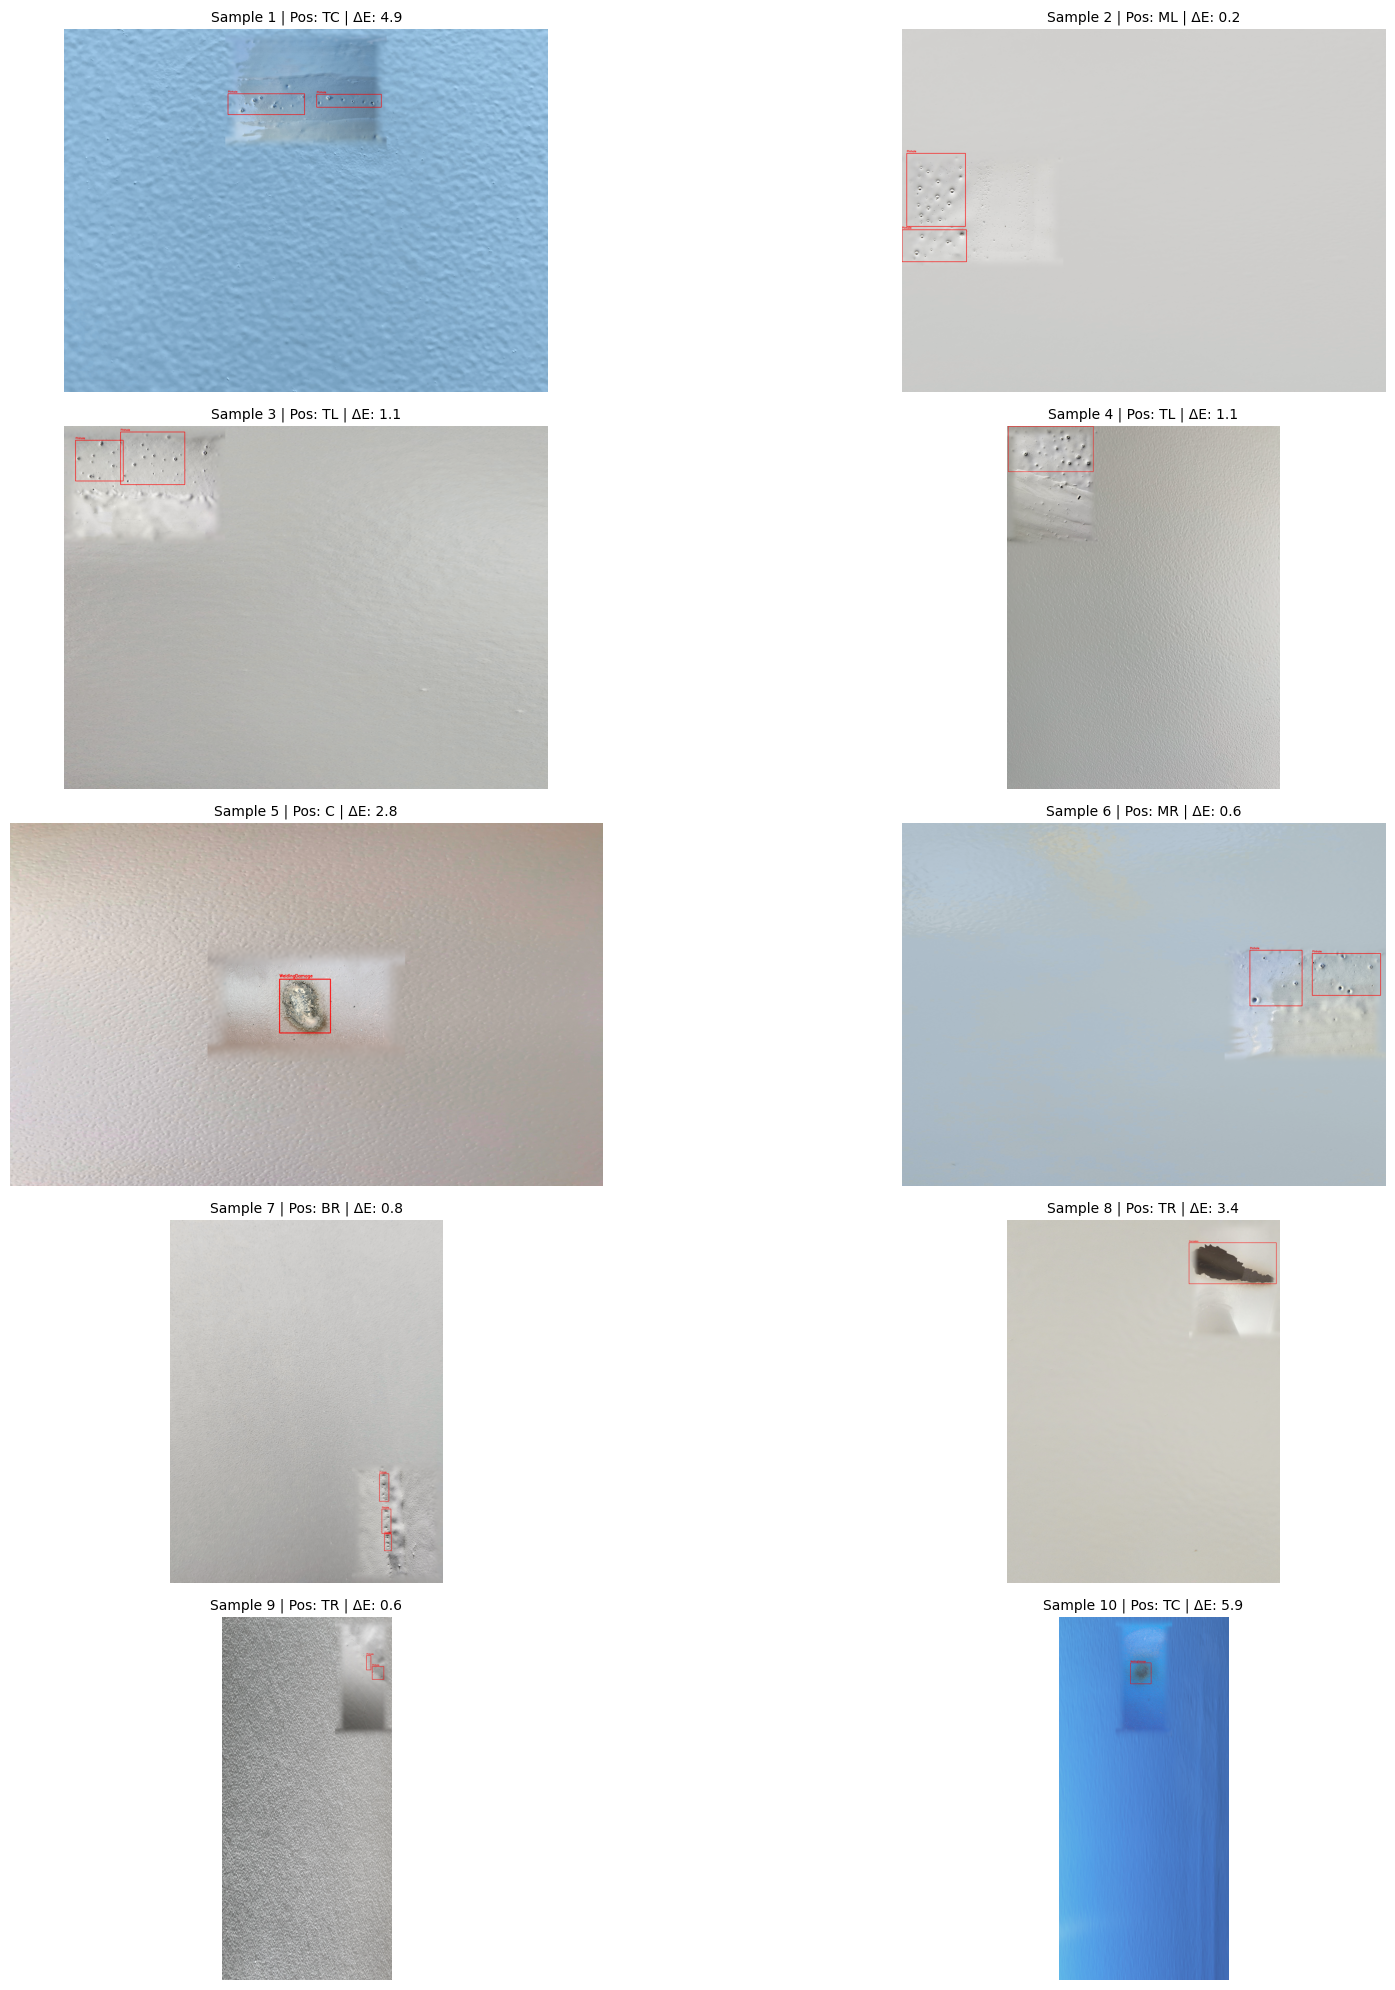


✅ 색상 전이 블렌딩 증강 시각화 완료!
💡 양품 이미지 색조를 불량 배경에 맞게 자동 조정
💡 100px 그라디언트 + 강한 블러 + 2단계 경계 블러
💡 ΔE 값이 작을수록 원본 배경 색상이 유사합니다.


In [24]:
import cv2
import numpy as np
import os
import random
import matplotlib.pyplot as plt

# 1. 경로 설정
base_path = r'C:\Users\SSAFY\Desktop\SafeDeck_Data'
train_img_dir = os.path.join(base_path, 'images', 'train')
train_lbl_dir = os.path.join(base_path, 'labels', 'train')
normal_img_dir = os.path.join(base_path, 'normal_images')

# 클래스 이름 (시각화 시 라벨 표시용)
class_names = ['WaterSpotting', 'Sagging', 'Peeling', 'Pinhole', 'Crack', 
               'Blistering', 'Inclusion', 'WeldingDamage', 'Scratch', 'Corrosion']

# 양품 이미지 리스트 확보
normal_files = [f for f in os.listdir(normal_img_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
print(f"✅ 양품 이미지: {len(normal_files)}장")


def apply_strong_edge_blur(img, mask, blur_kernel=25):
    """경계 부분에 초강력 블러 적용"""
    # 원본과 강한 블러 버전 생성
    blurred = cv2.GaussianBlur(img, (blur_kernel, blur_kernel), 0)
    
    # 마스크의 경계 부분 검출 (0.05 ~ 0.95 영역 = 더 넓은 경계)
    edge_mask = np.logical_and(mask > 0.05, mask < 0.95).astype(np.float32)
    
    # 경계 마스크도 블러 처리
    edge_mask = cv2.GaussianBlur(edge_mask, (15, 15), 5)
    edge_mask = edge_mask[:, :, np.newaxis] if edge_mask.ndim == 2 else edge_mask
    
    # 경계 부분만 강한 블러 적용
    result = img * (1 - edge_mask) + blurred * edge_mask
    
    return result.astype(np.uint8)


def generate_color_based_augmentation(img_name, normal_profiles, save=False):
    """색상 기반 양품 선택 + 색상 전이 + 초강력 블렌딩 증강"""
    # 1) 결함 이미지 및 라벨 로드
    defect_img = cv2.imread(os.path.join(train_img_dir, img_name))
    if defect_img is None: 
        return None, None, None, None
    h, w, c = defect_img.shape
    
    lbl_name = os.path.splitext(img_name)[0] + '.txt'
    lbl_path = os.path.join(train_lbl_dir, lbl_name)
    if not os.path.exists(lbl_path): 
        return None, None, None, None
    
    with open(lbl_path, 'r') as f:
        lines = f.readlines()
    
    # 2) 배경 색상 추출 (평균 + 표준편차)
    defect_bg_mean, defect_bg_std = extract_defect_background_color(defect_img, lines)
    
    # 3) 가장 유사한 양품 선택 (Top-1)
    selected_normal, color_distance = select_best_matching_normal_image(
        defect_bg_mean, normal_profiles
    )
    
    # 4) 양품 배경 이미지 로드 및 리사이즈
    normal_img = cv2.imread(os.path.join(normal_img_dir, selected_normal))
    normal_resized = cv2.resize(normal_img, (w, h))
    
    # 5) 🎨 색상 전이: 양품 이미지를 불량 이미지 색조에 맞게 조정
    background = color_transfer_lab(
        normal_resized,
        target_mean=defect_bg_mean,
        target_std=defect_bg_std * 0.7  # 표준편차는 70%만 적용 (너무 강하면 부자연스러움)
    )
    
    # 6) 3x3 그리드 중 랜덤 위치 선택 (0~8)
    grid_position = random.randint(0, 8)
    grid_row = grid_position // 3  # 0, 1, 2
    grid_col = grid_position % 3   # 0, 1, 2
    
    # 7) 결함 이미지를 1/3 크기로 축소
    defect_small_h = h // 3
    defect_small_w = w // 3
    defect_resized = cv2.resize(defect_img, (defect_small_w, defect_small_h))
    
    # 8) 배치 위치 계산
    start_y = grid_row * defect_small_h
    start_x = grid_col * defect_small_w
    end_y = start_y + defect_small_h
    end_x = start_x + defect_small_w
    
    # 9) 초강력 블렌딩 마스크 생성
    blend_mask = create_ultra_smooth_blend_mask(
        defect_small_h, defect_small_w, 
        blend_size=100,  # 매우 넓은 블렌딩 영역
        blur_strength=20  # 매우 강한 블러
    )
    
    # 10) 결함 영역 블렌딩
    roi = background[start_y:end_y, start_x:end_x].copy()
    
    # 기본 알파 블렌딩
    blended = (defect_resized * blend_mask + roi * (1 - blend_mask)).astype(np.uint8)
    
    # 경계 부분에 초강력 블러 적용 (2단계)
    blended = apply_strong_edge_blur(blended, blend_mask[:, :, 0], blur_kernel=21)
    blended = apply_strong_edge_blur(blended, blend_mask[:, :, 0], blur_kernel=15)
    
    background[start_y:end_y, start_x:end_x] = blended
    
    # 11) 전체 이미지에 약한 블러로 통일감 부여
    background = cv2.GaussianBlur(background, (5, 5), 0.5)
    
    # 12) 라벨 좌표 변환
    new_lines = []
    for line in lines:
        cls, x, y, nw, nh = map(float, line.split())
        
        # 원본 좌표를 1/3 크기로 축소
        scaled_x = x / 3
        scaled_y = y / 3
        scaled_w = nw / 3
        scaled_h = nh / 3
        
        # 그리드 위치에 따라 오프셋 추가
        offset_x = grid_col / 3
        offset_y = grid_row / 3
        
        new_x = scaled_x + offset_x
        new_y = scaled_y + offset_y
        new_w = scaled_w
        new_h = scaled_h
        
        new_lines.append(f"{int(cls)} {new_x:.6f} {new_y:.6f} {new_w:.6f} {new_h:.6f}\n")

    # 13) 저장 (옵션)
    if save:
        new_img_name = 'aug_color_' + img_name
        new_lbl_name = 'aug_color_' + lbl_name
        cv2.imwrite(os.path.join(train_img_dir, new_img_name), background)
        with open(os.path.join(train_lbl_dir, new_lbl_name), 'w') as f:
            f.writelines(new_lines)
        return background, new_lines, grid_position, color_distance
    
    return background, new_lines, grid_position, color_distance


# --- 샘플 10개 색상 기반 증강 및 시각화 ---
defect_files = [f for f in os.listdir(train_img_dir) 
                if f.lower().endswith(('.jpg', '.jpeg', '.png')) and not f.startswith('aug_')]

print(f"📁 전체 결함 이미지: {len(defect_files)}장")
print(f"🎨 색상 전이 + 초강력 블렌딩으로 샘플 10개 증강...\n")

# 랜덤으로 10개 선택
sample_files = random.sample(defect_files, min(10, len(defect_files)))

plt.figure(figsize=(20, 20))

for i, img_name in enumerate(sample_files):
    # 색상 기반 증강 수행
    aug_img, aug_labels, grid_pos, delta_e = generate_color_based_augmentation(
        img_name, normal_profiles, save=False
    )
    
    if aug_img is None:
        continue
    
    # BGR to RGB
    img = cv2.cvtColor(aug_img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape
    
    # 박스 그리기
    for lbl in aug_labels:
        cls, x, y, nw, nh = map(float, lbl.split())
        # 정규화된 좌표를 픽셀 좌표로 복원
        x1 = int((x - nw / 2) * w)
        y1 = int((y - nh / 2) * h)
        x2 = int((x + nw / 2) * w)
        y2 = int((y + nh / 2) * h)
        
        # 사각형 및 라벨 표시
        cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 3)
        cv2.putText(img, class_names[int(cls)], (x1, y1 - 10), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)

    # 출력
    plt.subplot(5, 2, i + 1)
    plt.imshow(img)
    
    # 그리드 위치 표시
    grid_position_map = {
        0: "TL", 1: "TC", 2: "TR",
        3: "ML", 4: "C", 5: "MR",
        6: "BL", 7: "BC", 8: "BR"
    }
    plt.title(f"Sample {i+1} | Pos: {grid_position_map[grid_pos]} | ΔE: {delta_e:.1f}", 
              fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

print("\n✅ 색상 전이 블렌딩 증강 시각화 완료!")
print("💡 양품 이미지 색조를 불량 배경에 맞게 자동 조정")
print("💡 100px 그라디언트 + 강한 블러 + 2단계 경계 블러")
print("💡 ΔE 값이 작을수록 원본 배경 색상이 유사합니다.")